In [1]:
from puffin import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
import numpy as np

puffin = Puffin(use_cuda=True)

/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/selene_sdk/sequences/genome.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def read_fasta_sequences(fasta_file):
    """读取FASTA文件并返回序列字典"""
    sequences = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequences[record.id] = str(record.seq)
    return sequences

def process_sequences(sequences_dict, target='FANTOM_CAGE'):
    """处理一组序列并返回平均解释结果"""
    sequences = list(sequences_dict.values())
    sequence_ids = list(sequences_dict.keys())
    
    # 初始化叠加矩阵
    total_interpretation = None
    
    # 循环处理每条序列
    for i, sequence in enumerate(sequences):
        # 使用Puffin进行解释
        interpretation = puffin.interpret(sequence, targeti=target)
        interpretation = interpretation.drop(['Coordinate','Sequence'])
        
        # 第一次初始化，后续累加
        if total_interpretation is None:
            total_interpretation = interpretation
        else:
            total_interpretation += interpretation
    
    # 除以总序列数得到平均值
    average_interpretation = total_interpretation / len(sequences)
    
    return average_interpretation, sequences, sequence_ids

def prepare_data_for_comparison(interpretation_data):
    """准备数据用于比较分析"""
    if isinstance(interpretation_data, pd.DataFrame):
        numeric_df = interpretation_data.apply(pd.to_numeric, errors='coerce')
    else:
        numeric_df = pd.DataFrame(interpretation_data)
    
    # 如果需要，进行log转换
    if numeric_df.max().max() > 20:  # 简单判断线性尺度
        numeric_df = np.log10(numeric_df + 1)
    
    return numeric_df


In [3]:
target = "FANTOM_CAGE"
# 读取case组数据
print("读取case组序列...")
case_fasta_file = "Puffin/p16_sen_broad_TSS_sequences.fasta"  # 请替换为实际的case组文件路径
case_sequences_dict = read_fasta_sequences(case_fasta_file)
case_average_interpretation, case_sequences, case_ids = process_sequences(case_sequences_dict)

# 读取control组数据  
print("读取control组序列...")
control_fasta_file = "Puffin/p12_young_broad_TSS_sequences.fasta"  # 请替换为实际的control组文件路径
control_sequences_dict = read_fasta_sequences(control_fasta_file)
control_average_interpretation, control_sequences, control_ids = process_sequences(control_sequences_dict)

# 准备数据用于比较
case_data = prepare_data_for_comparison(case_average_interpretation)
control_data = prepare_data_for_comparison(control_average_interpretation)

读取case组序列...
读取control组序列...


/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


In [4]:
# 定义中心区域范围（假设350bp序列，中心点在175bp位置）
sequence_length = 600
center_position = sequence_length // 2  # 175
window_size = 50

# 计算中心区域前后的索引范围
center_start = center_position - window_size  # 125
center_end = center_position + window_size   # 225

print(f"序列长度: {sequence_length}bp")
print(f"中心点位置: {center_position}")
print(f"分析窗口: 位置{center_start}到{center_end} (中心点前后{window_size}bp)")

# 计算case组中心区域平均信号
case_center_region = case_data.iloc[:, center_start:center_end+1]
case_center_avg = case_center_region.mean(axis=1)
print(f"Case组中心区域数据形状: {case_center_region.shape}")

# 计算control组中心区域平均信号  
control_center_region = control_data.iloc[:, center_start:center_end+1]
control_center_avg = control_center_region.mean(axis=1)
print(f"Control组中心区域数据形状: {control_center_region.shape}")

# 创建用于比较的对象
center_region_comparison = {
    'case': {
        'full_data': case_data,
        'center_region': case_center_region,
        'center_avg': case_center_avg,
        'description': 'Case组中心区域(前后50bp)平均信号'
    },
    'control': {
        'full_data': control_data,
        'center_region': control_center_region,
        'center_avg': control_center_avg,
        'description': 'Control组中心区域(前后50bp)平均信号'
    },
    'difference': {
        'center_avg_diff': case_center_avg - control_center_avg,
        'description': 'Case-Control中心区域平均信号差异'
    },
    'metadata': {
        'sequence_length': sequence_length,
        'center_position': center_position,
        'window_size': window_size,
        'analysis_region': f"位置{center_start}-{center_end}"
    }
}

print("\n中心区域比较对象创建完成！")
print(f"分析区域: {center_region_comparison['metadata']['analysis_region']}")
print(f"Case组平均信号对象包含 {len(case_center_avg)} 个factor")
print(f"Control组平均信号对象包含 {len(control_center_avg)} 个factor")

# 显示一些统计信息
print("\n中心区域平均信号统计:")
print("Case组:")
print(f"  最小值: {case_center_avg.min():.4f}")
print(f"  最大值: {case_center_avg.max():.4f}")
print(f"  平均值: {case_center_avg.mean():.4f}")

print("Control组:")
print(f"  最小值: {control_center_avg.min():.4f}")
print(f"  最大值: {control_center_avg.max():.4f}")
print(f"  平均值: {control_center_avg.mean():.4f}")

print("差异统计:")
diff_signals = center_region_comparison['difference']['center_avg_diff']
print(f"  最小差异: {diff_signals.min():.4f}")
print(f"  最大差异: {diff_signals.max():.4f}")
print(f"  平均差异: {diff_signals.mean():.4f}")

# 显示前几个factor的中心区域平均信号值
print("\n前5个factor的中心区域平均信号:")
for i, factor in enumerate(case_center_avg.index[:5]):
    case_val = case_center_avg[factor]
    control_val = control_center_avg[factor]
    diff_val = case_val - control_val
    print(f"  {factor}: Case={case_val:.4f}, Control={control_val:.4f}, Diff={diff_val:.4f}")

print("\n数据准备完成！现在可以开始两组比较分析。")
print("可用对象: center_region_comparison")
print("包含:")
print("  - case['center_avg']: Case组中心区域平均信号")
print("  - control['center_avg']: Control组中心区域平均信号") 
print("  - difference['center_avg_diff']: 两组差异")

序列长度: 600bp
中心点位置: 300
分析窗口: 位置250到350 (中心点前后50bp)
Case组中心区域数据形状: (78, 101)
Control组中心区域数据形状: (78, 101)

中心区域比较对象创建完成！
分析区域: 位置250-350
Case组平均信号对象包含 78 个factor
Control组平均信号对象包含 78 个factor

中心区域平均信号统计:
Case组:
  最小值: -0.0203
  最大值: 1.2990
  平均值: 0.1086
Control组:
  最小值: -0.0288
  最大值: 1.5248
  平均值: 0.1304
差异统计:
  最小差异: -0.2258
  最大差异: 0.0314
  平均差异: -0.0218

前5个factor的中心区域平均信号:
  Prediction: Case=0.0537, Control=0.0649, Diff=-0.0112
  CREB+ motif activation: Case=0.0023, Control=0.0026, Diff=-0.0003
  CREB- motif activation: Case=0.0022, Control=0.0025, Diff=-0.0003
  ETS+ motif activation: Case=0.0023, Control=0.0033, Diff=-0.0009
  ETS- motif activation: Case=0.0029, Control=0.0032, Diff=-0.0003

数据准备完成！现在可以开始两组比较分析。
可用对象: center_region_comparison
包含:
  - case['center_avg']: Case组中心区域平均信号
  - control['center_avg']: Control组中心区域平均信号
  - difference['center_avg_diff']: 两组差异


基于关键词筛选行并进行两组比较...
找到 4 个匹配关键词的行
匹配的行:
  - Sum of initiator effect
  - Sum of total effect
  - Sum of trinucleotide effect
  - Sum of motif effect

按差异排序的结果:
                     Factor      Case   Control  Difference
    Sum of initiator effect -0.010418 -0.019220    0.008802
Sum of trinucleotide effect  0.168398  0.188218   -0.019820
        Sum of motif effect  0.551875  0.582610   -0.030736
        Sum of total effect  0.608870  0.642203   -0.033333


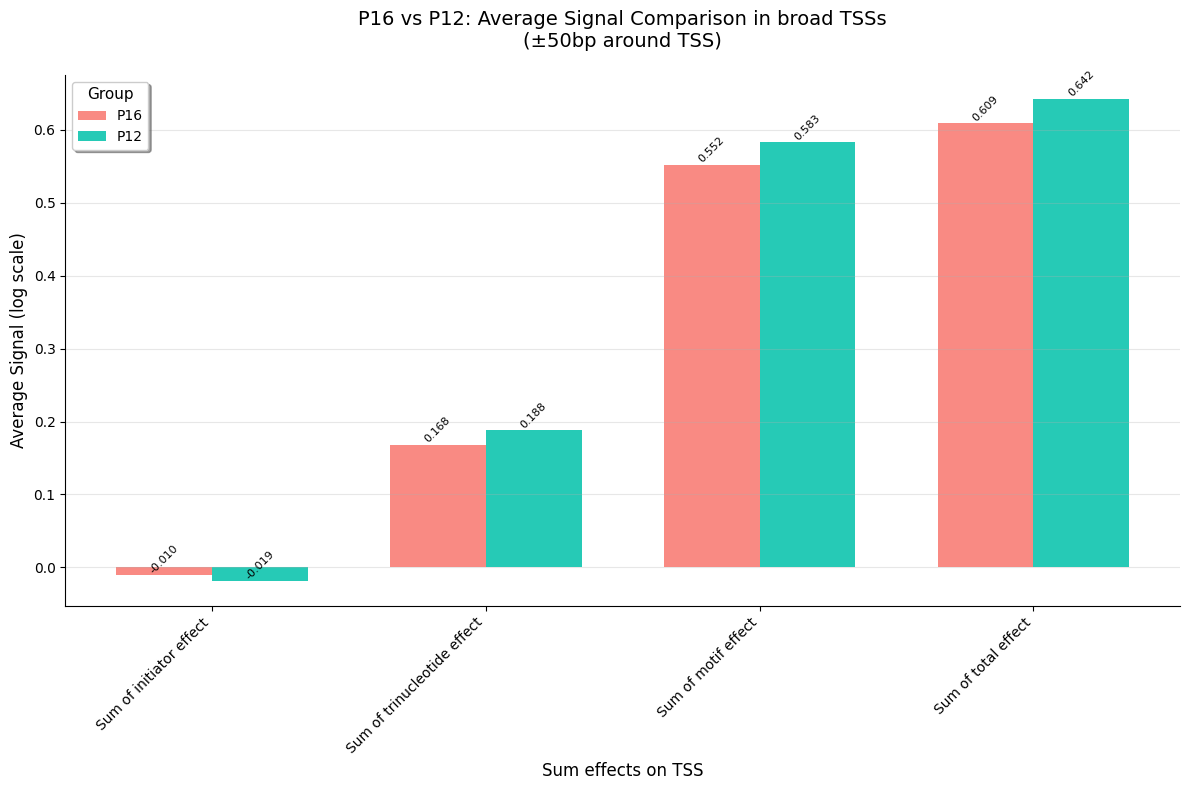

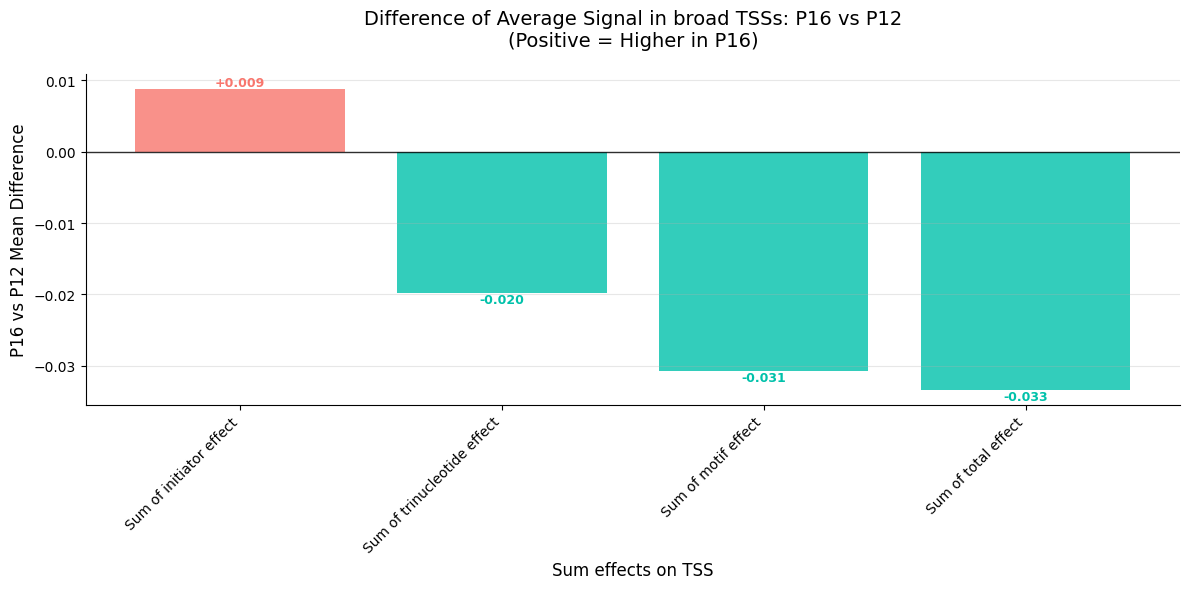


差异统计:
  P09信号更高的factor数量: 1
  P03信号更高的factor数量: 3
  无差异的factor数量: 0

P09信号最高的前3个factor:
  Sum of initiator effect: +0.0088

P03信号最高的前3个factor:
  Sum of trinucleotide effect: -0.0198
  Sum of motif effect: -0.0307
  Sum of total effect: -0.0333

分析完成！


In [5]:
# 基于关键词筛选行并进行两组比较
print("基于关键词筛选行并进行两组比较...")

# 定义要筛选的关键词列表
keywords = ["sum"]

# 收集所有匹配的行
matching_rows = set()
for keyword in keywords:
    case_matches = case_data.index[case_data.index.str.contains(keyword, case=False, na=False)]
    control_matches = control_data.index[control_data.index.str.contains(keyword, case=False, na=False)]
    matching_rows.update(case_matches)
    matching_rows.update(control_matches)

matching_rows = list(matching_rows)
print(f"找到 {len(matching_rows)} 个匹配关键词的行")

if len(matching_rows) > 0:
    print("匹配的行:")
    for row in matching_rows:
        print(f"  - {row}")
    
    # 提取这些行在中心区域的平均信号值
    case_selected = center_region_comparison['case']['center_avg'].loc[matching_rows]
    control_selected = center_region_comparison['control']['center_avg'].loc[matching_rows]
    
    # 创建比较数据框
    comparison_df = pd.DataFrame({
        'Factor': matching_rows,
        'Case': case_selected.values,
        'Control': control_selected.values
    })
    
    # 计算差异并按差异大小排序
    comparison_df['Difference'] = comparison_df['Case'] - comparison_df['Control']
    comparison_df = comparison_df.sort_values('Difference', ascending=False)
    
    print("\n按差异排序的结果:")
    print(comparison_df.to_string(index=False))
    
    # ✅ 修改组别注释（真实组名）
    group_name_mapping = {
        'Case': 'P16',
        'Control': 'P12'
    }

    comparison_df = comparison_df.rename(columns=group_name_mapping)

    # =========================
    # 图1：两组平均信号柱状图
    # =========================
    plt.figure(figsize=(12, 8))
    
    x = np.arange(len(comparison_df))
    width = 0.35

    bars1 = plt.bar(x - width/2, comparison_df['P16'], width, 
                    label='P16', color='#F8766D', alpha=0.85)
    bars2 = plt.bar(x + width/2, comparison_df['P12'], width, 
                    label='P12', color='#00C1AA', alpha=0.85)

    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.3f}',
                     ha='center', va='bottom', fontsize=8, rotation=45)

    if len(comparison_df) <= 20:
        add_value_labels(bars1)
        add_value_labels(bars2)

    plt.xlabel('Sum effects on TSS', fontsize=12)
    plt.ylabel('Average Signal (log scale)', fontsize=12)
    plt.title('P16 vs P12: Average Signal Comparison in broad TSSs\n(±50bp around TSS)', fontsize=14, pad=20)
    plt.xticks(x, comparison_df['Factor'], rotation=45, ha='right')
    plt.legend(title='Group', title_fontsize=11, fontsize=10,
               frameon=True, fancybox=True, shadow=True)
    plt.grid(axis='y', alpha=0.3)
    sns.despine()
    plt.tight_layout()

    # ✅ 保存为 PDF（文字可编辑）
    plt.savefig('P16_vs_P12_sum_broad_average_signal.pdf', format='pdf', bbox_inches='tight')

    plt.show()

    # =========================
    # 图2：差异柱状图（橘红↑，翠绿↓）
    # =========================
    plt.figure(figsize=(12, 6))

    # ✅ 改进颜色逻辑：上升=橘红 (#F8766D)，下降=翠绿 (#00C1AA)
    colors = ['#F8766D' if diff > 0 else '#00C1AA' for diff in comparison_df['Difference']]

    bars = plt.bar(comparison_df['Factor'], comparison_df['Difference'], color=colors, alpha=0.8)

    plt.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)

    for bar in bars:
        height = bar.get_height()
        if height != 0:
            va = 'bottom' if height > 0 else 'top'
            color = '#F8766D' if height > 0 else '#00C1AA'  # 深橘/深绿文字
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:+.3f}',
                     ha='center', va=va, fontsize=9, color=color, weight='bold')

    plt.xlabel('Sum effects on TSS', fontsize=12)
    plt.ylabel('P16 vs P12 Mean Difference', fontsize=12)
    plt.title('Difference of Average Signal in broad TSSs: P16 vs P12\n(Positive = Higher in P16)', fontsize=14, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    sns.despine()
    plt.tight_layout()

    # ✅ 保存为 PDF（文字可编辑）
    plt.savefig('P16_vs_P12_sum_broad_signal_difference.pdf', format='pdf', bbox_inches='tight')

    plt.show()

    # =========================
    # 差异统计输出
    # =========================
    positive_diff = (comparison_df['Difference'] > 0).sum()
    negative_diff = (comparison_df['Difference'] < 0).sum()
    zero_diff = (comparison_df['Difference'] == 0).sum()
    
    print(f"\n差异统计:")
    print(f"  P09信号更高的factor数量: {positive_diff}")
    print(f"  P03信号更高的factor数量: {negative_diff}")
    print(f"  无差异的factor数量: {zero_diff}")
    
    if positive_diff > 0:
        top_positive = comparison_df[comparison_df['Difference'] > 0].head(3)
        print(f"\nP09信号最高的前3个factor:")
        for _, row in top_positive.iterrows():
            print(f"  {row['Factor']}: +{row['Difference']:.4f}")
    
    if negative_diff > 0:
        top_negative = comparison_df[comparison_df['Difference'] < 0].head(3)
        print(f"\nP03信号最高的前3个factor:")
        for _, row in top_negative.iterrows():
            print(f"  {row['Factor']}: {row['Difference']:.4f}")
    
else:
    print("没有找到匹配关键词的行，请尝试其他关键词")

print("\n分析完成！")


基于关键词筛选行并进行两组比较...
找到 19 个匹配关键词的行
匹配的行:
  - YY1+ motif effect
  - NFY- motif effect
  - TATA- motif effect
  - NRF1+ motif effect
  - CREB- motif effect
  - ZNF143- motif effect
  - U1 snRNP- motif effect
  - CREB+ motif effect
  - SP+ motif effect
  - ETS- motif effect
  - SP- motif effect
  - NFY+ motif effect
  - TATA+ motif effect
  - YY1- motif effect
  - ZNF143+ motif effect
  - ETS+ motif effect
  - Sum of motif effect
  - NRF1- motif effect
  - U1 snRNP+ motif effect

按差异排序的结果:
                Factor      Case   Control  Difference
      SP+ motif effect  0.151125  0.119710    0.031415
      SP- motif effect  0.143290  0.136809    0.006481
    CREB- motif effect  0.045124  0.044206    0.000918
    CREB+ motif effect  0.060722  0.060936   -0.000214
    TATA+ motif effect  0.021605  0.021900   -0.000295
U1 snRNP- motif effect -0.020274 -0.019417   -0.000857
    TATA- motif effect  0.013358  0.014912   -0.001554
  ZNF143- motif effect  0.007153  0.012968   -0.005815
     YY1- moti

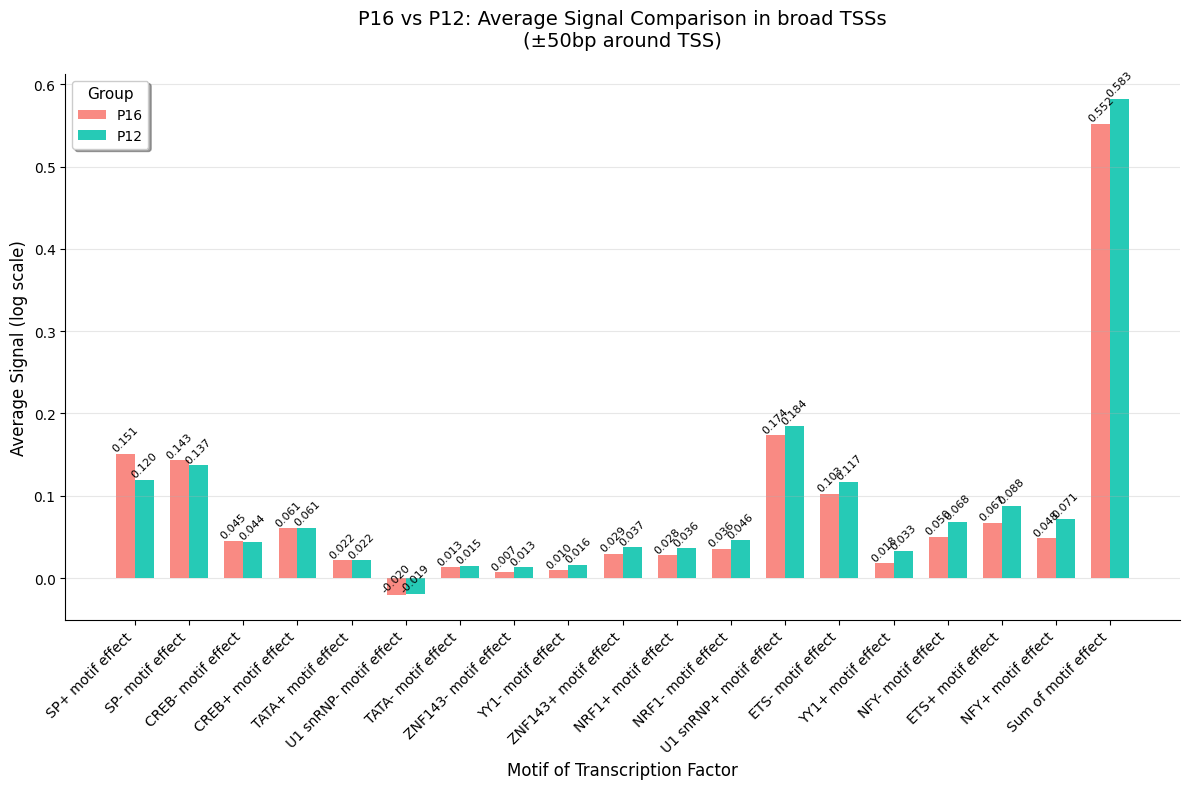

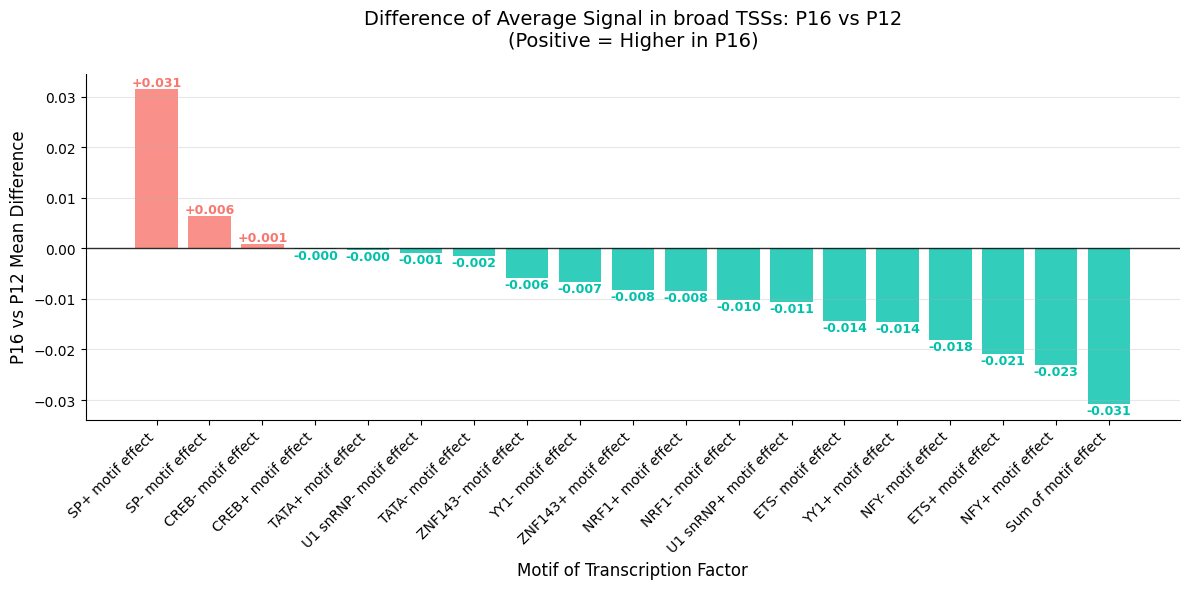


差异统计:
  P09信号更高的factor数量: 3
  P03信号更高的factor数量: 16
  无差异的factor数量: 0

P09信号最高的前3个factor:
  SP+ motif effect: +0.0314
  SP- motif effect: +0.0065
  CREB- motif effect: +0.0009

P03信号最高的前3个factor:
  CREB+ motif effect: -0.0002
  TATA+ motif effect: -0.0003
  U1 snRNP- motif effect: -0.0009

分析完成！


In [6]:
# 基于关键词筛选行并进行两组比较
print("基于关键词筛选行并进行两组比较...")

# 定义要筛选的关键词列表
keywords = ["motif effect"]

# 收集所有匹配的行
matching_rows = set()
for keyword in keywords:
    case_matches = case_data.index[case_data.index.str.contains(keyword, case=False, na=False)]
    control_matches = control_data.index[control_data.index.str.contains(keyword, case=False, na=False)]
    matching_rows.update(case_matches)
    matching_rows.update(control_matches)

matching_rows = list(matching_rows)
print(f"找到 {len(matching_rows)} 个匹配关键词的行")

if len(matching_rows) > 0:
    print("匹配的行:")
    for row in matching_rows:
        print(f"  - {row}")
    
    # 提取这些行在中心区域的平均信号值
    case_selected = center_region_comparison['case']['center_avg'].loc[matching_rows]
    control_selected = center_region_comparison['control']['center_avg'].loc[matching_rows]
    
    # 创建比较数据框
    comparison_df = pd.DataFrame({
        'Factor': matching_rows,
        'Case': case_selected.values,
        'Control': control_selected.values
    })
    
    # 计算差异并按差异大小排序
    comparison_df['Difference'] = comparison_df['Case'] - comparison_df['Control']
    comparison_df = comparison_df.sort_values('Difference', ascending=False)
    
    print("\n按差异排序的结果:")
    print(comparison_df.to_string(index=False))
    
    # ✅ 修改组别注释（真实组名）
    group_name_mapping = {
        'Case': 'P16',
        'Control': 'P12'
    }

    comparison_df = comparison_df.rename(columns=group_name_mapping)

    # =========================
    # 图1：两组平均信号柱状图
    # =========================
    plt.figure(figsize=(12, 8))
    
    x = np.arange(len(comparison_df))
    width = 0.35

    bars1 = plt.bar(x - width/2, comparison_df['P16'], width, 
                    label='P16', color='#F8766D', alpha=0.85)
    bars2 = plt.bar(x + width/2, comparison_df['P12'], width, 
                    label='P12', color='#00C1AA', alpha=0.85)

    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.3f}',
                     ha='center', va='bottom', fontsize=8, rotation=45)

    if len(comparison_df) <= 20:
        add_value_labels(bars1)
        add_value_labels(bars2)

    plt.xlabel('Motif of Transcription Factor', fontsize=12)
    plt.ylabel('Average Signal (log scale)', fontsize=12)
    plt.title('P16 vs P12: Average Signal Comparison in broad TSSs\n(±50bp around TSS)', fontsize=14, pad=20)
    plt.xticks(x, comparison_df['Factor'], rotation=45, ha='right')
    plt.legend(title='Group', title_fontsize=11, fontsize=10,
               frameon=True, fancybox=True, shadow=True)
    plt.grid(axis='y', alpha=0.3)
    sns.despine()
    plt.tight_layout()

    # ✅ 保存为 PDF（文字可编辑）
    plt.savefig('P16_vs_P12_broad_average_signal.pdf', format='pdf', bbox_inches='tight')

    plt.show()

    # =========================
    # 图2：差异柱状图（橘红↑，翠绿↓）
    # =========================
    plt.figure(figsize=(12, 6))

    # ✅ 改进颜色逻辑：上升=橘红 (#F8766D)，下降=翠绿 (#00C1AA)
    colors = ['#F8766D' if diff > 0 else '#00C1AA' for diff in comparison_df['Difference']]

    bars = plt.bar(comparison_df['Factor'], comparison_df['Difference'], color=colors, alpha=0.8)

    plt.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)

    for bar in bars:
        height = bar.get_height()
        if height != 0:
            va = 'bottom' if height > 0 else 'top'
            color = '#F8766D' if height > 0 else '#00C1AA'  # 深橘/深绿文字
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:+.3f}',
                     ha='center', va=va, fontsize=9, color=color, weight='bold')

    plt.xlabel('Motif of Transcription Factor', fontsize=12)
    plt.ylabel('P16 vs P12 Mean Difference', fontsize=12)
    plt.title('Difference of Average Signal in broad TSSs: P16 vs P12\n(Positive = Higher in P16)', fontsize=14, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    sns.despine()
    plt.tight_layout()

    # ✅ 保存为 PDF（文字可编辑）
    plt.savefig('P16_vs_P12_broad_signal_difference.pdf', format='pdf', bbox_inches='tight')

    plt.show()

    # =========================
    # 差异统计输出
    # =========================
    positive_diff = (comparison_df['Difference'] > 0).sum()
    negative_diff = (comparison_df['Difference'] < 0).sum()
    zero_diff = (comparison_df['Difference'] == 0).sum()
    
    print(f"\n差异统计:")
    print(f"  P09信号更高的factor数量: {positive_diff}")
    print(f"  P03信号更高的factor数量: {negative_diff}")
    print(f"  无差异的factor数量: {zero_diff}")
    
    if positive_diff > 0:
        top_positive = comparison_df[comparison_df['Difference'] > 0].head(3)
        print(f"\nP09信号最高的前3个factor:")
        for _, row in top_positive.iterrows():
            print(f"  {row['Factor']}: +{row['Difference']:.4f}")
    
    if negative_diff > 0:
        top_negative = comparison_df[comparison_df['Difference'] < 0].head(3)
        print(f"\nP03信号最高的前3个factor:")
        for _, row in top_negative.iterrows():
            print(f"  {row['Factor']}: {row['Difference']:.4f}")
    
else:
    print("没有找到匹配关键词的行，请尝试其他关键词")

print("\n分析完成！")


In [7]:
# 重新设计数据处理流程，保留每条序列的个体数据
print("重新设计数据处理流程，保留每条序列的个体数据...")

def process_individual_sequences(sequences_dict, target='FANTOM_CAGE'):
    """处理一组序列并返回每条序列的解释结果"""
    sequences = list(sequences_dict.values())
    sequence_ids = list(sequences_dict.keys())
    
    # 存储每条序列的解释结果
    individual_interpretations = []
    
    # 循环处理每条序列
    for i, sequence in enumerate(sequences):
        # 使用Puffin进行解释
        interpretation = puffin.interpret(sequence, targeti=target)
        interpretation = interpretation.drop(['Coordinate','Sequence'])
        
        # 存储单条序列的解释结果
        individual_interpretations.append(interpretation)
        
        if (i + 1) % 10 == 0:  # 每10条序列打印一次进度
            print(f"已处理 {i+1}/{len(sequences)} 条序列")
    
    return individual_interpretations, sequences, sequence_ids

def extract_center_region_individual(individual_interpretations, center_start=250, center_end=350):
    """从每条序列的解释结果中提取中心区域数据"""
    center_region_data = []
    
    for i, interpretation in enumerate(individual_interpretations):
        # 准备数据
        if isinstance(interpretation, pd.DataFrame):
            numeric_df = interpretation.apply(pd.to_numeric, errors='coerce')
        else:
            numeric_df = pd.DataFrame(interpretation)
        
        # 判断是否需要log转换
        if numeric_df.max().max() > 20:
            numeric_df = np.log10(numeric_df + 1)
        
        # 提取中心区域并计算每行的平均值
        center_region = numeric_df.iloc[:, center_start:center_end+1]
        row_means = center_region.mean(axis=1)
        
        center_region_data.append(row_means)
    
    # 将所有序列的数据组合成一个DataFrame
    # 行: factor/motif, 列: 序列
    combined_data = pd.concat(center_region_data, axis=1)
    combined_data.columns = [f"seq_{i}" for i in range(len(individual_interpretations))]
    
    return combined_data

# 处理case组数据（保留每条序列）
print("处理case组序列（保留个体数据）...")
case_individual_interpretations, case_sequences, case_ids = process_individual_sequences(case_sequences_dict)
case_individual_center_data = extract_center_region_individual(case_individual_interpretations)

# 处理control组数据（保留每条序列）
print("处理control组序列（保留个体数据）...")
control_individual_interpretations, control_sequences, control_ids = process_individual_sequences(control_sequences_dict)
control_individual_center_data = extract_center_region_individual(control_individual_interpretations)

print(f"Case组个体数据形状: {case_individual_center_data.shape}")  # (factors, sequences)
print(f"Control组个体数据形状: {control_individual_center_data.shape}")

# 创建用于统计检验的数据结构
statistical_comparison = {
    'case': {
        'individual_data': case_individual_center_data,  # 每条序列的中心区域平均信号
        'group_mean': case_individual_center_data.mean(axis=1),  # 组平均值
        'description': 'Case组个体序列数据'
    },
    'control': {
        'individual_data': control_individual_center_data,
        'group_mean': control_individual_center_data.mean(axis=1),
        'description': 'Control组个体序列数据'
    },
    'metadata': {
        'case_sample_size': case_individual_center_data.shape[1],
        'control_sample_size': control_individual_center_data.shape[1],
        'num_factors': case_individual_center_data.shape[0],
        'analysis_region': f"位置{125}-{225}"
    }
}

print("\n个体数据准备完成！")
print(f"Case组样本数: {statistical_comparison['metadata']['case_sample_size']}")
print(f"Control组样本数: {statistical_comparison['metadata']['control_sample_size']}")
print(f"分析的factor数量: {statistical_comparison['metadata']['num_factors']}")

# 显示一些基本信息
print("\n前5个factor的组平均值:")
for i, factor in enumerate(statistical_comparison['case']['group_mean'].index[:5]):
    case_mean = statistical_comparison['case']['group_mean'][factor]
    control_mean = statistical_comparison['control']['group_mean'][factor]
    print(f"  {factor}: Case={case_mean:.4f}, Control={control_mean:.4f}")

print("\n现在可以进行统计检验和p值计算！")
print("可用数据:")
print("- statistical_comparison['case']['individual_data']: Case组个体数据")
print("- statistical_comparison['control']['individual_data']: Control组个体数据")
print("- statistical_comparison['case']['group_mean']: Case组平均值")
print("- statistical_comparison['control']['group_mean']: Control组平均值")

重新设计数据处理流程，保留每条序列的个体数据...
处理case组序列（保留个体数据）...
已处理 10/2240 条序列
已处理 20/2240 条序列
已处理 30/2240 条序列
已处理 40/2240 条序列
已处理 50/2240 条序列
已处理 60/2240 条序列
已处理 70/2240 条序列
已处理 80/2240 条序列
已处理 90/2240 条序列
已处理 100/2240 条序列
已处理 110/2240 条序列
已处理 120/2240 条序列
已处理 130/2240 条序列
已处理 140/2240 条序列
已处理 150/2240 条序列
已处理 160/2240 条序列
已处理 170/2240 条序列
已处理 180/2240 条序列
已处理 190/2240 条序列
已处理 200/2240 条序列
已处理 210/2240 条序列
已处理 220/2240 条序列
已处理 230/2240 条序列
已处理 240/2240 条序列
已处理 250/2240 条序列
已处理 260/2240 条序列
已处理 270/2240 条序列
已处理 280/2240 条序列
已处理 290/2240 条序列
已处理 300/2240 条序列
已处理 310/2240 条序列
已处理 320/2240 条序列
已处理 330/2240 条序列
已处理 340/2240 条序列
已处理 350/2240 条序列
已处理 360/2240 条序列
已处理 370/2240 条序列
已处理 380/2240 条序列
已处理 390/2240 条序列
已处理 400/2240 条序列
已处理 410/2240 条序列
已处理 420/2240 条序列
已处理 430/2240 条序列
已处理 440/2240 条序列
已处理 450/2240 条序列
已处理 460/2240 条序列
已处理 470/2240 条序列
已处理 480/2240 条序列
已处理 490/2240 条序列
已处理 500/2240 条序列
已处理 510/2240 条序列
已处理 520/2240 条序列
已处理 530/2240 条序列
已处理 540/2240 条序列
已处理 550/2240 条序列
已处理 560/2240 条序列
已处理 570/22

/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python

处理control组序列（保留个体数据）...
已处理 10/2610 条序列
已处理 20/2610 条序列
已处理 30/2610 条序列
已处理 40/2610 条序列
已处理 50/2610 条序列
已处理 60/2610 条序列
已处理 70/2610 条序列
已处理 80/2610 条序列
已处理 90/2610 条序列
已处理 100/2610 条序列
已处理 110/2610 条序列
已处理 120/2610 条序列
已处理 130/2610 条序列
已处理 140/2610 条序列
已处理 150/2610 条序列
已处理 160/2610 条序列
已处理 170/2610 条序列
已处理 180/2610 条序列
已处理 190/2610 条序列
已处理 200/2610 条序列
已处理 210/2610 条序列
已处理 220/2610 条序列
已处理 230/2610 条序列
已处理 240/2610 条序列
已处理 250/2610 条序列
已处理 260/2610 条序列
已处理 270/2610 条序列
已处理 280/2610 条序列
已处理 290/2610 条序列
已处理 300/2610 条序列
已处理 310/2610 条序列
已处理 320/2610 条序列
已处理 330/2610 条序列
已处理 340/2610 条序列
已处理 350/2610 条序列
已处理 360/2610 条序列
已处理 370/2610 条序列
已处理 380/2610 条序列
已处理 390/2610 条序列
已处理 400/2610 条序列
已处理 410/2610 条序列
已处理 420/2610 条序列
已处理 430/2610 条序列
已处理 440/2610 条序列
已处理 450/2610 条序列
已处理 460/2610 条序列
已处理 470/2610 条序列
已处理 480/2610 条序列
已处理 490/2610 条序列
已处理 500/2610 条序列
已处理 510/2610 条序列
已处理 520/2610 条序列
已处理 530/2610 条序列
已处理 540/2610 条序列
已处理 550/2610 条序列
已处理 560/2610 条序列
已处理 570/2610 条序列
已处理 580/2610 条序列

/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python

Case组个体数据形状: (78, 2240)
Control组个体数据形状: (78, 2610)

个体数据准备完成！
Case组样本数: 2240
Control组样本数: 2610
分析的factor数量: 78

前5个factor的组平均值:
  Prediction: Case=0.0450, Control=0.0551
  CREB+ motif activation: Case=0.0018, Control=0.0020
  CREB- motif activation: Case=0.0017, Control=0.0020
  ETS+ motif activation: Case=0.0014, Control=0.0019
  ETS- motif activation: Case=0.0017, Control=0.0018

现在可以进行统计检验和p值计算！
可用数据:
- statistical_comparison['case']['individual_data']: Case组个体数据
- statistical_comparison['control']['individual_data']: Control组个体数据
- statistical_comparison['case']['group_mean']: Case组平均值
- statistical_comparison['control']['group_mean']: Control组平均值


/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
/home/jiaqi/miniforge3/envs/puffin/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


In [8]:
# 进行统计检验
print("进行统计检验...")

from scipy import stats

def calculate_statistics(case_data, control_data):
    """计算两组数据的统计指标"""
    results = []
    
    for factor in case_data.index:
        case_values = case_data.loc[factor].values
        control_values = control_data.loc[factor].values
        
        # 基本统计量
        case_mean = np.mean(case_values)
        control_mean = np.mean(control_values)
        mean_diff = case_mean - control_mean
        
        # t检验
        t_stat, p_value = stats.ttest_ind(case_values, control_values, equal_var=False)
        
        # 效应量 (Cohen's d)
        pooled_std = np.sqrt((np.var(case_values, ddof=1) + np.var(control_values, ddof=1)) / 2)
        cohens_d = mean_diff / pooled_std if pooled_std != 0 else 0
        
        results.append({
            'Factor': factor,
            'Case_Mean': case_mean,
            'Control_Mean': control_mean,
            'Mean_Difference': mean_diff,
            'T_Statistic': t_stat,
            'P_Value': p_value,
            'Cohen_D': cohens_d,
            'Case_Std': np.std(case_values, ddof=1),
            'Control_Std': np.std(control_values, ddof=1)
        })
    
    return pd.DataFrame(results)

# 计算所有factor的统计指标
statistics_df = calculate_statistics(
    statistical_comparison['case']['individual_data'],
    statistical_comparison['control']['individual_data']
)

# 按p值排序
statistics_df_sorted = statistics_df.sort_values('P_Value')

print("统计检验完成！")
print(f"总共分析了 {len(statistics_df)} 个factor")

# 显示显著性结果
significant_threshold = 0.05
significant_factors = statistics_df[statistics_df['P_Value'] < significant_threshold]
print(f"在p<{significant_threshold}水平下显著的factor数量: {len(significant_factors)}")

if len(significant_factors) > 0:
    print("\n最显著的10个factor:")
    print(significant_factors.head(10)[['Factor', 'P_Value', 'Mean_Difference', 'Cohen_D']].to_string(index=False))

# 保存统计结果
statistical_comparison['statistics'] = statistics_df_sorted
statistical_comparison['significant_factors'] = significant_factors

print("\n统计检验完成！现在可以基于p值进行可视化。")

进行统计检验...
统计检验完成！
总共分析了 78 个factor
在p<0.05水平下显著的factor数量: 59

最显著的10个factor:
                Factor      P_Value  Mean_Difference   Cohen_D
            Prediction 3.218783e-09        -0.010144 -0.170826
CREB+ motif activation 4.839283e-03        -0.000181 -0.080684
CREB- motif activation 5.460379e-04        -0.000212 -0.099299
 ETS+ motif activation 9.261614e-10        -0.000492 -0.175204
 NFY+ motif activation 2.311619e-02        -0.000081 -0.064854
 NFY- motif activation 5.623718e-05        -0.000161 -0.115009
NRF1+ motif activation 2.388493e-06        -0.000356 -0.135525
NRF1- motif activation 1.976715e-04        -0.000263 -0.106998
  SP+ motif activation 3.224381e-05         0.000589  0.120284
  SP- motif activation 9.880791e-04         0.000397  0.094954

统计检验完成！现在可以基于p值进行可视化。


准备绘制箱型图...
找到 19 个匹配关键词的行
绘图数据形状: (92150, 3)


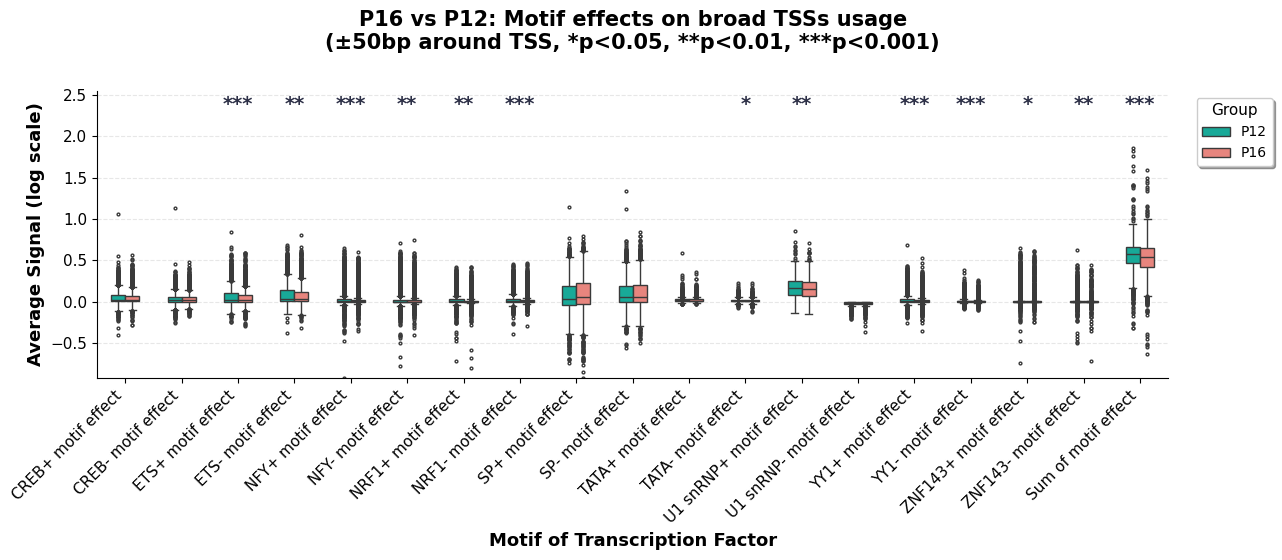

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

print("准备绘制箱型图...")

# 基于关键词筛选行
keywords = ["motif effect"]
matching_rows = set()

for keyword in keywords:
    case_matches = statistical_comparison['case']['individual_data'].index[
        statistical_comparison['case']['individual_data'].index.str.contains(keyword, case=False, na=False)
    ]
    control_matches = statistical_comparison['control']['individual_data'].index[
        statistical_comparison['control']['individual_data'].index.str.contains(keyword, case=False, na=False)
    ]
    
    matching_rows.update(case_matches)
    matching_rows.update(control_matches)

# 将匹配的行转换为列表，并按照原始数据中的顺序排序
all_rows = statistical_comparison['case']['individual_data'].index.tolist()
matching_rows = [row for row in all_rows if row in matching_rows]

print(f"找到 {len(matching_rows)} 个匹配关键词的行")

if len(matching_rows) == 0:
    print("没有找到匹配关键词的行，使用所有行进行绘图")
    matching_rows = statistical_comparison['case']['individual_data'].index.tolist()

# 筛选统计结果
selected_stats = statistical_comparison['statistics'][
    statistical_comparison['statistics']['Factor'].isin(matching_rows)
].copy()

# 准备绘图数据 - 转换为长格式
def prepare_boxplot_data(case_data, control_data, selected_factors):
    """准备用于绘制箱型图的数据"""
    boxplot_data = []
    
    for factor in selected_factors:
        # Case组数据
        case_values = case_data.loc[factor].values
        for value in case_values:
            boxplot_data.append({
                'Factor': factor,
                'Group': 'Case',
                'Value': value
            })
        
        # Control组数据
        control_values = control_data.loc[factor].values
        for value in control_values:
            boxplot_data.append({
                'Factor': factor,
                'Group': 'Control',
                'Value': value
            })
    
    return pd.DataFrame(boxplot_data)

# 准备绘图数据
boxplot_df = prepare_boxplot_data(
    statistical_comparison['case']['individual_data'],
    statistical_comparison['control']['individual_data'],
    matching_rows
)

# 确保Factor列为分类变量，并按照原始顺序排序
boxplot_df['Factor'] = pd.Categorical(
    boxplot_df['Factor'], 
    categories=matching_rows, 
    ordered=True
)

print(f"绘图数据形状: {boxplot_df.shape}")

# -------------------------------
# ✅ 修改组别注释（真实组名）
# -------------------------------
group_name_mapping = {
    'Control': 'P12',      # 原Control组 -> 实验中的对照组名
    'Case': 'P16'     # 原Case组 -> 实验中的处理组名
}
boxplot_df['Group'] = boxplot_df['Group'].replace(group_name_mapping)

# Nature风格配色方案
nature_colors = {
    'P12': '#00C1AA',      # 蓝绿色系 - Control在左侧
    'P16': '#F8766D'  # 橘红色系 - Case在右侧
}

# 设置图形参数 - 纵向高度压缩1/4
n_factors = len(matching_rows)
fig_width = max(12, n_factors * 0.8)
fig_height = 6

# 创建图形
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# 绘制箱型图
sns.boxplot(
    data=boxplot_df, 
    x='Factor', 
    y='Value', 
    hue='Group',
    hue_order=['P12', 'P16'],
    palette=nature_colors,
    fliersize=2,
    linewidth=1.0,   # ✅ 边框更细
    width=0.5,
    ax=ax,
    order=matching_rows
)

# 计算全局y轴范围
all_values = boxplot_df['Value']
global_y_min = all_values.min()
global_y_max = all_values.max()
y_range = global_y_max - global_y_min

# 添加显著性标记
for i, factor in enumerate(matching_rows):
    factor_stats = selected_stats[selected_stats['Factor'] == factor]
    if len(factor_stats) > 0:
        p_value = factor_stats['P_Value'].values[0]
        
        if p_value < 0.001:
            sig_symbol = '***'
        elif p_value < 0.01:
            sig_symbol = '**'
        elif p_value < 0.05:
            sig_symbol = '*'
        else:
            sig_symbol = ''
        
        if sig_symbol:
            y_pos = global_y_max + y_range * 0.15
            ax.text(i, y_pos, sig_symbol, 
                   ha='center', va='bottom', 
                   fontsize=14, fontweight='bold',
                   color='#2D3047')

# 设置图表属性
ax.set_xlabel('Motif of Transcription Factor', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Signal (log scale)', fontsize=13, fontweight='bold')
ax.set_title('P16 vs P12: Motif effects on broad TSSs usage\n(±50bp around TSS, *p<0.05, **p<0.01, ***p<0.001)', 
             fontsize=15, pad=30, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
ax.set_ylim(global_y_min, global_y_max + y_range * 0.25)

ax.legend(title='Group', title_fontsize=11, fontsize=10, 
          loc='upper left', bbox_to_anchor=(1.02, 1),
          frameon=True, fancybox=True, shadow=True)

ax.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 0.95])

# -------------------------------
# ✅ 保存为PDF格式（文字可编辑）
# -------------------------------
plt.savefig('P16VSP12_broad_TSS_comparison.pdf', format='pdf', bbox_inches='tight')

plt.show()


准备绘制箱型图...
找到 4 个匹配关键词的行
绘图数据形状: (19400, 3)


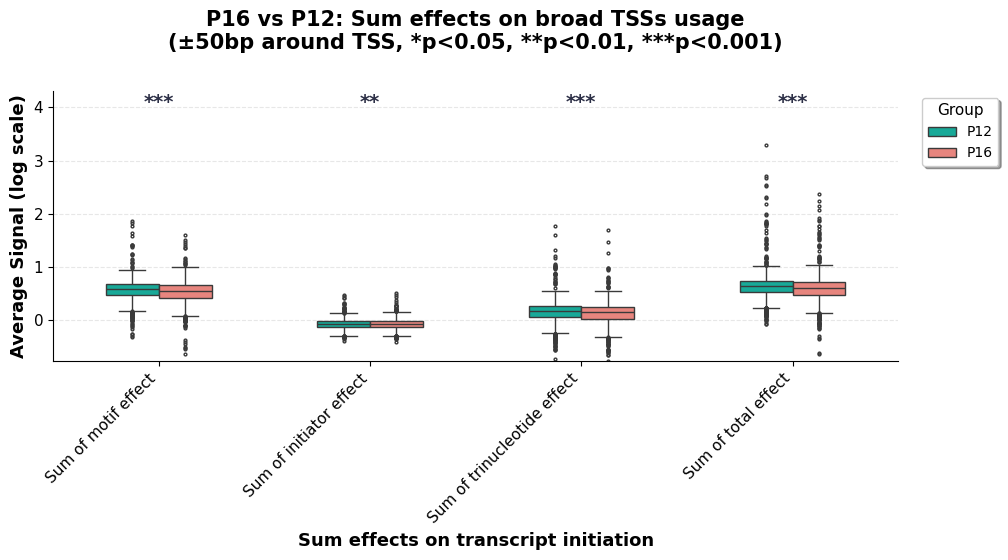

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

print("准备绘制箱型图...")

# 基于关键词筛选行
keywords = ["sum"]
matching_rows = set()

for keyword in keywords:
    case_matches = statistical_comparison['case']['individual_data'].index[
        statistical_comparison['case']['individual_data'].index.str.contains(keyword, case=False, na=False)
    ]
    control_matches = statistical_comparison['control']['individual_data'].index[
        statistical_comparison['control']['individual_data'].index.str.contains(keyword, case=False, na=False)
    ]
    
    matching_rows.update(case_matches)
    matching_rows.update(control_matches)

# 将匹配的行转换为列表，并按照原始数据中的顺序排序
all_rows = statistical_comparison['case']['individual_data'].index.tolist()
matching_rows = [row for row in all_rows if row in matching_rows]

print(f"找到 {len(matching_rows)} 个匹配关键词的行")

if len(matching_rows) == 0:
    print("没有找到匹配关键词的行，使用所有行进行绘图")
    matching_rows = statistical_comparison['case']['individual_data'].index.tolist()

# 筛选统计结果
selected_stats = statistical_comparison['statistics'][
    statistical_comparison['statistics']['Factor'].isin(matching_rows)
].copy()

# 准备绘图数据 - 转换为长格式
def prepare_boxplot_data(case_data, control_data, selected_factors):
    """准备用于绘制箱型图的数据"""
    boxplot_data = []
    
    for factor in selected_factors:
        # Case组数据
        case_values = case_data.loc[factor].values
        for value in case_values:
            boxplot_data.append({
                'Factor': factor,
                'Group': 'Case',
                'Value': value
            })
        
        # Control组数据
        control_values = control_data.loc[factor].values
        for value in control_values:
            boxplot_data.append({
                'Factor': factor,
                'Group': 'Control',
                'Value': value
            })
    
    return pd.DataFrame(boxplot_data)

# 准备绘图数据
boxplot_df = prepare_boxplot_data(
    statistical_comparison['case']['individual_data'],
    statistical_comparison['control']['individual_data'],
    matching_rows
)

# 确保Factor列为分类变量，并按照原始顺序排序
boxplot_df['Factor'] = pd.Categorical(
    boxplot_df['Factor'], 
    categories=matching_rows, 
    ordered=True
)

print(f"绘图数据形状: {boxplot_df.shape}")

# -------------------------------
# ✅ 修改组别注释（真实组名）
# -------------------------------
group_name_mapping = {
    'Control': 'P12',      # 原Control组 -> 实验中的对照组名
    'Case': 'P16'     # 原Case组 -> 实验中的处理组名
}
boxplot_df['Group'] = boxplot_df['Group'].replace(group_name_mapping)

# Nature风格配色方案
nature_colors = {
    'P12': '#00C1AA',      # 蓝绿色系 - Control在左侧
    'P16': '#F8766D'  # 橘红色系 - Case在右侧
}

# 设置图形参数 - 纵向高度压缩1/4
n_factors = len(matching_rows)
fig_width = max(12, n_factors * 0.8)
fig_height = 6

# 创建图形
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# 绘制箱型图
sns.boxplot(
    data=boxplot_df, 
    x='Factor', 
    y='Value', 
    hue='Group',
    hue_order=['P12', 'P16'],
    palette=nature_colors,
    fliersize=2,
    linewidth=1.0,   # ✅ 边框更细
    width=0.5,
    ax=ax,
    order=matching_rows
)

# 计算全局y轴范围
all_values = boxplot_df['Value']
global_y_min = all_values.min()
global_y_max = all_values.max()
y_range = global_y_max - global_y_min

# 添加显著性标记
for i, factor in enumerate(matching_rows):
    factor_stats = selected_stats[selected_stats['Factor'] == factor]
    if len(factor_stats) > 0:
        p_value = factor_stats['P_Value'].values[0]
        
        if p_value < 0.001:
            sig_symbol = '***'
        elif p_value < 0.01:
            sig_symbol = '**'
        elif p_value < 0.05:
            sig_symbol = '*'
        else:
            sig_symbol = ''
        
        if sig_symbol:
            y_pos = global_y_max + y_range * 0.15
            ax.text(i, y_pos, sig_symbol, 
                   ha='center', va='bottom', 
                   fontsize=14, fontweight='bold',
                   color='#2D3047')

# 设置图表属性
ax.set_xlabel('Sum effects on transcript initiation', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Signal (log scale)', fontsize=13, fontweight='bold')
ax.set_title('P16 vs P12: Sum effects on broad TSSs usage\n(±50bp around TSS, *p<0.05, **p<0.01, ***p<0.001)', 
             fontsize=15, pad=30, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
ax.set_ylim(global_y_min, global_y_max + y_range * 0.25)

ax.legend(title='Group', title_fontsize=11, fontsize=10, 
          loc='upper left', bbox_to_anchor=(1.02, 1),
          frameon=True, fancybox=True, shadow=True)

ax.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 0.95])

# -------------------------------
# ✅ 保存为PDF格式（文字可编辑）
# -------------------------------
plt.savefig('P16VSP12_broad_sum_TSS_comparison.pdf', format='pdf', bbox_inches='tight')

plt.show()


In [27]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# from scipy import stats

# print("准备绘制箱型图...")

# # 基于关键词筛选行
# keywords = ["motif effect"]
# matching_rows = set()

# for keyword in keywords:
#     case_matches = statistical_comparison['case']['individual_data'].index[
#         statistical_comparison['case']['individual_data'].index.str.contains(keyword, case=False, na=False)
#     ]
#     control_matches = statistical_comparison['control']['individual_data'].index[
#         statistical_comparison['control']['individual_data'].index.str.contains(keyword, case=False, na=False)
#     ]
    
#     matching_rows.update(case_matches)
#     matching_rows.update(control_matches)

# # 将匹配的行转换为列表，并按照原始数据中的顺序排序
# # 获取原始数据中的所有行，然后筛选出匹配的行，保持原始顺序
# all_rows = statistical_comparison['case']['individual_data'].index.tolist()
# matching_rows = [row for row in all_rows if row in matching_rows]

# print(f"找到 {len(matching_rows)} 个匹配关键词的行")

# if len(matching_rows) == 0:
#     print("没有找到匹配关键词的行，使用所有行进行绘图")
#     matching_rows = statistical_comparison['case']['individual_data'].index.tolist()

# # 筛选统计结果
# selected_stats = statistical_comparison['statistics'][
#     statistical_comparison['statistics']['Factor'].isin(matching_rows)
# ].copy()

# # 准备绘图数据 - 转换为长格式
# def prepare_boxplot_data(case_data, control_data, selected_factors):
#     """准备用于绘制箱型图的数据"""
#     boxplot_data = []
    
#     for factor in selected_factors:
#         # Case组数据
#         case_values = case_data.loc[factor].values
#         for value in case_values:
#             boxplot_data.append({
#                 'Factor': factor,
#                 'Group': 'Case',
#                 'Value': value
#             })
        
#         # Control组数据
#         control_values = control_data.loc[factor].values
#         for value in control_values:
#             boxplot_data.append({
#                 'Factor': factor,
#                 'Group': 'Control',
#                 'Value': value
#             })
    
#     return pd.DataFrame(boxplot_data)

# # 准备绘图数据
# boxplot_df = prepare_boxplot_data(
#     statistical_comparison['case']['individual_data'],
#     statistical_comparison['control']['individual_data'],
#     matching_rows
# )

# # 确保Factor列为分类变量，并按照原始顺序排序
# boxplot_df['Factor'] = pd.Categorical(
#     boxplot_df['Factor'], 
#     categories=matching_rows, 
#     ordered=True
# )

# print(f"绘图数据形状: {boxplot_df.shape}")

# # Nature风格配色方案
# nature_colors = {
#     'Control': '#00C1AA',  # 蓝绿色系 - Control在左侧
#     'Case': '#F8766D'      # 橘红色系 - Case在右侧
# }

# # 设置图形参数 - 纵向高度压缩1/4
# n_factors = len(matching_rows)
# fig_width = max(12, n_factors * 0.8)  # 根据因子数量调整宽度
# fig_height = 6  # 从8压缩到6，压缩了1/4

# # 创建图形
# fig, ax = plt.subplots(figsize=(fig_width, fig_height))



# # 绘制箱型图 - 调整width参数使箱子更瘦
# sns.boxplot(
#     data=boxplot_df, 
#     x='Factor', 
#     y='Value', 
#     hue='Group',
#     hue_order=['Control', 'Case'],  # Control在左侧，Case在右侧
#     palette=nature_colors,
#     fliersize=2,  # 异常点大小
#     linewidth=1.2,  # 箱线宽度
#     width=0.5,  # 减小width值使箱子更瘦（默认约0.8）
#     ax=ax,
#     order=matching_rows  # 确保按照原始顺序排序
# )

# # 计算全局y轴范围，用于统一设置显著性标记位置
# all_values = boxplot_df['Value']
# global_y_min = all_values.min()
# global_y_max = all_values.max()
# y_range = global_y_max - global_y_min

# # 添加显著性标记
# for i, factor in enumerate(matching_rows):
#     # 获取该因子的p值
#     factor_stats = selected_stats[selected_stats['Factor'] == factor]
#     if len(factor_stats) > 0:
#         p_value = factor_stats['P_Value'].values[0]
        
#         # 确定显著性标记
#         if p_value < 0.001:
#             sig_symbol = '***'
#         elif p_value < 0.01:
#             sig_symbol = '**'
#         elif p_value < 0.05:
#             sig_symbol = '*'
#         else:
#             sig_symbol = ''  # 不显著则不标记
        
#         # 添加显著性标记
#         if sig_symbol:
#             # 使用全局y范围计算标记位置，确保所有标记在同一高度
#             y_pos = global_y_max + y_range * 0.15  # 统一使用全局最大值上方15%范围的位置
            
#             # 在图上添加文本
#             ax.text(i, y_pos, sig_symbol, 
#                    ha='center', va='bottom', 
#                    fontsize=14, fontweight='bold',
#                    color='#2D3047')

# # 设置图表属性
# ax.set_xlabel('Factors/Motifs', fontsize=13, fontweight='bold')
# ax.set_ylabel('Average Signal in Center Region (log scale)', fontsize=13, fontweight='bold')
# ax.set_title('P09 vs P03: Distribution Comparison in Center Region\n(±50bp around center, *p<0.05, **p<0.01, ***p<0.001)', 
#              fontsize=15, pad=30, fontweight='bold')  # 增加pad值使标题更高

# # 旋转x轴标签以避免重叠
# plt.xticks(rotation=45, ha='right', fontsize=11)

# # 设置y轴标签字体
# plt.yticks(fontsize=11)

# # 调整y轴范围，为显著性标记留出空间
# ax.set_ylim(global_y_min, global_y_max + y_range * 0.25)  # 为标记留出25%的额外空间

# # 添加图例 - 移动到整张图的右上角，不遮挡数据
# # 使用bbox_to_anchor将图例放置在绘图区域之外
# ax.legend(title='Group', title_fontsize=11, fontsize=10, 
#           loc='upper left', bbox_to_anchor=(1.02, 1),  # 将图例放在绘图区域右侧
#           frameon=True, fancybox=True, shadow=True)

# # 添加网格线
# ax.grid(axis='y', alpha=0.3, linestyle='--')
# sns.despine()

# # 使用tight_layout并调整右侧边距，为图例留出空间
# plt.tight_layout(rect=[0, 0, 0.85, 0.95])  # 调整右侧边距，为图例留出15%的空间

# # 保存为SVG矢量图 - 在show()之前保存
# plt.savefig('case_control_comparison.svg', format='svg', bbox_inches='tight', dpi=300)
# print("主图已保存为: case_control_comparison.svg")

# plt.show()


    
# # 在您现有的绘图代码最后添加：